In [2]:
# our based Model is DeepSeek Coder 1.3b instruct, fine tune with seperate data category from one data. 
# Implementing PEFT and QLora
# This is Fine Tuning model page
model_name = "deepseek-ai/deepseek-coder-1.3b-instruct"
FIM_PREFIX = "<fim_prefix>"
FIM_SUFFIX = "<fim_suffix>"
FIM_MIDDLE = "<fim_middle>"


In [1]:
DETECTION_SYSTEM_PROMPT = """You are a C++ code expert specializing in detecting code smells in game engines. Analyze the provided C++ code snippet for code smells, prioritizing game-specific ones below.
- When you receive a code snippet separated into <fim_prefix>, <fim_suffix>, <fim_middle>, treat it as three parts: prefix, middle, suffix. Focus detection on the middle but use prefix and suffix for overall context.
- For non-gap inputs, analyze the full snippet as three logical parts: prefix, middle, and suffix.
- Game-Specific Smells (prioritize these)= 
  [ 1. Creating components/objects at run-time (design/logic, severity context: 83%)
  2. Weak temporization strategy (design/logic, severity context: 80%)
  3. Lack of separation of concerns (design/logic/maintainability, severity context: 77%)
  4. Bloated asset (design/logic, severity context: 63%)
  5. Poor design of object state management (design/logic, severity context: 63%)
  6. Search by string/ID (design/logic, severity context: 53%)
  7. Dependencies between objects (design/logic, severity context: 48%)
  8. Prefer static classes instead of singleton (design/logic, severity context: 33%)
  9. Static coupling (design/logic, severity context: 32%)
  10. Allocating and destroying GameObjects in updates (performance)
  11. Getting GameObject by name (performance)
  12. Heavyweight Update methods (performance)
  13. Coupling objects through the Inspector (maintainability; adapt to C++ equivalents like direct dependencies)]
- For severity: Use provided % for design/logic smells; infer for others (0 for clean).
- Output ALWAYS in this exact JSON format (no extra text, valid JSON only):
{
  "smells":
  [  // List of smell objects; empty [] if none
    {
      "type": "smell_type1",  // e.g., "Heavyweight Update methods"; could be more
      "severity": int,  // Overall 0-100 (e.g., average or max per smell; use provided % where applicable)
      "explanation": "brief overall description"  // e.g., "No smells detected" if clean
    }
  ]
}


Examples:
1. Smelly full snippet input: "Detect code smells in this code: <snippet> 
   Output: {"smells": [exact Json format]
2. Clean full snippet input: "Detect code smells in this C++: <snippet>"
   Output: {"smells": []}
3. Smelly gap input: "Detect smells in the gap: <fim_prefix> { GameObject* obj = new GameObject(); <fim_suffix> /* heavy logic */ }<fim_middle>"
   Output: {"smells": [{"type": "Allocating and destroying GameObjects in updates", "severity": 90, "explanation": "Dynamic allocation in update loop impacts performance"}]}
4. Clean gap input: "Detect smells in the gap: <fim_prefix> code <fim_suffix> <fim_middle>"
   Output: {"smells": []}
5. Smelly code snippet input:"Detect Code smells in this code: <snippet>
   Output: {"smells": [exact Json format]
"""

In [4]:
FIXING_SYSTEM_PROMPT = """You are a C++ code expert specializing in fixing code smells in game engines. Based on detected smells, refactor the provided C++ code snippet, prioritizing game-specific fixes.
- When you receive a code snippet separated into <fim_prefix>, <fim_suffix>, <fim_middle>, treat it as three parts: prefix, middle, suffix. Focus fixes on the middle but use prefix and suffix for overall context.
- For non-gap inputs, analyze the full snippet as three logical parts: prefix, middle, suffix.
- Game-Specific Smells (prioritize these)= 
  [ 1. Creating components/objects at run-time (design/logic, severity context: 83%)
  2. Weak temporization strategy (design/logic, severity context: 80%)
  3. Lack of separation of concerns (design/logic/maintainability, severity context: 77%)
  4. Bloated asset (design/logic, severity context: 63%)
  5. Poor design of object state management (design/logic, severity context: 63%)
  6. Search by string/ID (design/logic, severity context: 53%)
  7. Dependencies between objects (design/logic, severity context: 48%)
  8. Prefer static classes instead of singleton (design/logic, severity context: 33%)
  9. Static coupling (design/logic, severity context: 32%)
  10. Allocating and destroying GameObjects in updates (performance)
  11. Getting GameObject by name (performance)
  12. Heavyweight Update methods (performance)
  13. Coupling objects through the Inspector (maintainability; adapt to C++ equivalents like direct dependencies)]
- For severity: Use provided % for design/logic smells; infer for others (0 for clean).
- Output ALWAYS in this exact JSON format (no extra text, valid JSON only):
{
  "fixed_code": "corrected_code_snippet",  // The refactored/filled C++ code
  "explanations": [  // List of fix explanations; empty [] if none
    {
      "smell_type": "smell_type1",  // e.g., "Heavyweight Update methods"
      "fix_description": "brief description of fix"  // e.g., "Optimized update loop"
    },
  ]
}


Examples:
1. Smelly full snippet input: "Fill and fix this code with smells ['Heavyweight Update methods']: void Update() { GameObject* obj = new GameObject(); /* heavy logic */ }"
   Output: {"fixed_code": "void Update() { /* optimized light logic */ }", "explanations": [{"smell_type": "Heavyweight Update methods", "fix_description": "Removed heavy allocation and simplified logic"}]}
2. Clean full snippet input: "Fill and fix this code: void Update() { /* light logic */ }"
   Output: {"fixed_code": "void Update() { /* light logic */ }", "explanations": []}
3. Smelly gap input: "Fill and fix the gap with smells ['Allocating and destroying GameObjects in updates']: <fim_prefix>void Update() { GameObject* obj = new GameObject(); <fim_suffix> /* heavy logic */ }<fim_middle>"
   Output: {"fixed_code": "void Update() { /* reused obj */ /* optimized logic */ }", "explanations": [{"smell_type": "Allocating and destroying GameObjects in updates", "fix_description": "Reused object instead of dynamic allocation in middle"}]}
4. Clean gap input: "Fill and fix the gap: <fim_prefix>void Update() { <fim_suffix> }<fim_middle>"
   Output: {"fixed_code": "void Update() { }", "explanations": []}
5. Smelly code snippet input: "Fill and fix this code with smells ['Lack of separation of concerns']: <snippet>"
   Output: {"fixed_code": "<refactored snippet>", "explanations": [{"smell_type": "Lack of separation of concerns", "fix_description": "Separated concerns into modules"}]}
"""

In [5]:
import json
import os
import re
import time
import torch
from pathlib import Path
from typing import List, Dict
from datasets import Dataset, load_from_disk
from transformers import (
    AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, TrainingArguments, pipeline, TrainerCallback
)
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training, PeftModel
from trl import SFTTrainer, SFTConfig
from accelerate import Accelerator, infer_auto_device_map, dispatch_model
from sklearn.metrics import precision_recall_fscore_support
import evaluate  # For ROUGE/BLEU
import gc  # For memory management
import matplotlib.pyplot as plt
from transformers import TrainerCallback
from bitsandbytes.nn import Linear8bitLt
import pandas as pd  # For CSV export

In [6]:
from concurrent.futures import ThreadPoolExecutor, as_completed
import numpy as np
from tqdm import tqdm
import csv
from datetime import datetime
from sklearn.metrics import precision_recall_fscore_support, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
import warnings 
warnings.filterwarnings('ignore')

In [8]:
# Data Loading and Splitting
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.model_max_length = 2048

In [9]:
def collect_files_by_type(root_path: str) -> Dict[str, List[str]]:
    """
    Recursively collect JSONL files from root_path, group by type.
    Print found files for verification.
    """
    root = Path(root_path)
    if not root.exists() or not root.is_dir():
        print(f"Error: Directory '{root_path}' does not exist or is not a directory.")
        print("Suggestions:")
        print("- Verify the path in File Explorer (e.g., remove spaces or check typos like 'game_engine_parse_code').")
        print("- Check permissions or if it's a file instead of dir.")
        parent_dir = root.parent
        if parent_dir.exists():
            print(f"Contents of parent dir {parent_dir}: {os.listdir(parent_dir)}")
        return {"detection": [], "fixing": []}  # Return empty to continue without crash
    
    detection_files = []
    fixing_files = []
    
    print(f"Scanning directory: {root_path}")
    # Recursively find all *.jsonl
    for file in root.rglob("*.jsonl"):
        print(f"Found JSONL file: {file}")  # Print each found file to "see" them
        filename = file.name.lower()
        if "detection" in filename:
            detection_files.append(str(file))
            print(f" - Classified as detection: {file}")
        elif "fixing" in filename:
            fixing_files.append(str(file))
            print(f" - Classified as fixing: {file}")
        else:
            print(f"Warning: Skipping untyped file {file}")
    
    return {"detection": detection_files, "fixing": fixing_files}

def load_jsonl_by_type(files_by_type: Dict[str, List[str]], validate: bool = True) -> Dict[str, List[Dict]]:
    """
    Load and validate JSONL per type.
    """
    datasets_raw = {"detection": [], "fixing": []}
    expected_keys = {"instruction", "output"}
    
    for dataset_type, files in files_by_type.items():
        if not files:
            print(f"No files for {dataset_type}")
            continue
        
        for file_path in files:
            print(f"Loading {dataset_type} file: {file_path}...")
            with open(file_path, 'r', encoding='utf-8') as f:
                for line_num, line in enumerate(f, 1):
                    try:
                        data = json.loads(line.strip())
                        if validate and not expected_keys.issubset(data.keys()):
                            print(f"Warning: Line {line_num} in {file_path} missing keys {expected_keys - set(data.keys())}")
                            continue
                        datasets_raw[dataset_type].append(data)
                    except json.JSONDecodeError:
                        print(f"Error: Invalid JSON at line {line_num} in {file_path}")
    
    for dtype, data in datasets_raw.items():
        print(f"Loaded {len(data)} entries for {dtype}")
    
    return datasets_raw

# Updated path as per your message
root_path = r"D:\dev\game engine parse code"  # Raw string for Windows
files_by_type = collect_files_by_type(root_path)
datasets_raw = load_jsonl_by_type(files_by_type)

Scanning directory: D:\dev\game engine parse code
Found JSONL file: D:\dev\game engine parse code\cafu\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\cafu\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cafu\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine parse code\cafu\fixing_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cocos2d-x\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\cocos2d-x\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cocos2d-x\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine parse code\cocos2d-x\fixing_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\Defold\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\Defold\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\Defold\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine pars

In [16]:
# data spitting
datasets = {}
for dtype, raw_data in datasets_raw.items():
    if not raw_data:
        continue
    dataset = Dataset.from_list(raw_data)
    dataset = dataset.train_test_split(test_size=0.2, seed=42)
    datasets[dtype] = {"train": dataset["train"], "val": dataset["test"]}
    print(f"{dtype.capitalize()} - Train: {len(dataset['train'])}, Val: {len(dataset['test'])}")

if "detection" not in datasets:
    print("Simulating detection dataset.")
    raw_detection = [{"instruction": "Detect smells in: int main() {}", "output": "{\"smells\": []}"}]
    dataset = Dataset.from_list(raw_detection)
    dataset = dataset.train_test_split(test_size=0.2, seed=42)
    datasets["detection"] = {"train": dataset["train"], "val": dataset["test"]}

if "fixing" not in datasets:
    print("Simulating fixing dataset.")
    raw_fixing = [{"instruction": "Fix smells in: int main() {}", "output": "{\"fixed_code\": \"int main() {}\"}"}]
    dataset = Dataset.from_list(raw_fixing)
    dataset = dataset.train_test_split(test_size=0.2, seed=42)
    datasets["fixing"] = {"train": dataset["train"], "val": dataset["test"]}

Detection - Train: 16720, Val: 4180
Fixing - Train: 16720, Val: 4180


In [17]:
# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    model_name,  # Defined earlier as "deepseek-ai/deepseek-coder-1.3b-instruct"
    trust_remote_code=True  # Required for DeepSeek's custom tokenizer config
)
# Set pad token to EOS for proper padding in batches (essential for QLoRA/SFTTrainer)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left"  # Recommended for causal LM to avoid shifting issues


In [12]:
# Custom prompt function (removed use_fim; simplified)
def create_custom_prompt(system_prompt: str, instruction: str, use_middle_eos: bool = False) -> str:
    bos_token = tokenizer.bos_token or ""
    eos_token = tokenizer.eos_token
    prompt = f"{bos_token}[INST] {system_prompt}\n\n{instruction} [/INST]"
    if use_middle_eos:
        prompt = f"{bos_token}[INST] {system_prompt}\n\nReason step-by-step:\n\n{instruction} [/INST]"
    return prompt

In [18]:
# Preprocess function 
def preprocess_dataset(examples: Dict[str, List], system_prompt: str, use_middle_eos: bool = False) -> Dict[str, List]:
    instructions = examples['instruction']
    outputs = examples['output']
    texts = []
    expert_prefix = "As a C++ code expert specializing in detecting and fixing code smells in game engines, "  # Trim this if duplicated
    for instruction, output in zip(instructions, outputs):
        # Fix duplication: Trim expert prefix from instruction if present (case-insensitive)
        if instruction.lower().startswith(expert_prefix.lower()):
            instruction = instruction[len(expert_prefix):]
        
        # Detect if gap (assume <fim_middle> is always at the end)
        is_gap = instruction.endswith('<fim_middle>')
        if is_gap:
            # Strip trailing <fim_middle> to avoid duplication
            instruction = instruction[:-len('<fim_middle>')]
        
        prompt = create_custom_prompt(system_prompt, instruction, use_middle_eos)
        
        # Insert <fim_middle> only for gaps, before output
        prefix_output = FIM_MIDDLE if is_gap else ""
        full_output = f"{prefix_output}{output}"
        
        # Append EOS only if not already at end (strip whitespace for check)
        eos_token = tokenizer.eos_token
        if not full_output.strip().endswith(eos_token):
            full_output += eos_token
        
        texts.append(f"{prompt} {full_output}")
    return {"text": texts}

In [19]:
# Detection preprocessing (no middle EOS)
processed_detection_train = datasets["detection"]["train"].map(
    lambda ex: preprocess_dataset(ex, DETECTION_SYSTEM_PROMPT, use_middle_eos=False),
    batched=True,
    remove_columns=datasets["detection"]["train"].column_names
)
processed_detection_val = datasets["detection"]["val"].map(
    lambda ex: preprocess_dataset(ex, DETECTION_SYSTEM_PROMPT, use_middle_eos=False),
    batched=True,
    remove_columns=datasets["detection"]["val"].column_names
)

# Save (same as before)
os.makedirs("processed_datasets/detection", exist_ok=True)
processed_detection_train.save_to_disk("processed_datasets/detection/train")
processed_detection_val.save_to_disk("processed_datasets/detection/val")

# View one full sample from train set
print("Detection Train Sample (first one, full text):")
for i in range(1):  # Only the first sample
    sample_text = processed_detection_train[i]["text"]
    print(f"Sample {i+1}:\n{sample_text}\n{'-'*80}")

Map:   0%|          | 0/16720 [00:00<?, ? examples/s]

Map:   0%|          | 0/4180 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/16720 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4180 [00:00<?, ? examples/s]

Detection Train Sample (first one, full text):
Sample 1:
<｜begin▁of▁sentence｜>[INST] You are a C++ code expert specializing in detecting code smells in game engines. Analyze the provided C++ code snippet for code smells, prioritizing game-specific ones below.
- When you receive a code snippet separated into <fim_prefix>, <fim_suffix>, <fim_middle>, treat it as three parts: prefix, middle, suffix. Focus detection on the middle but use prefix and suffix for overall context.
- For non-gap inputs, analyze the full snippet as three logical parts: prefix, middle, and suffix.
- Game-Specific Smells (prioritize these)= 
  [ 1. Creating components/objects at run-time (design/logic, severity context: 83%)
  2. Weak temporization strategy (design/logic, severity context: 80%)
  3. Lack of separation of concerns (design/logic/maintainability, severity context: 77%)
  4. Bloated asset (design/logic, severity context: 63%)
  5. Poor design of object state management (design/logic, severity context: 

In [20]:
# Fixing preprocessing 
processed_fixing_train = datasets["fixing"]["train"].map(
    lambda ex: preprocess_dataset(ex, FIXING_SYSTEM_PROMPT, use_middle_eos=True),
    batched=True,
    remove_columns=datasets["fixing"]["train"].column_names
)
processed_fixing_val = datasets["fixing"]["val"].map(
    lambda ex: preprocess_dataset(ex, FIXING_SYSTEM_PROMPT, use_middle_eos=True),
    batched=True,
    remove_columns=datasets["fixing"]["val"].column_names
)

# Save (same as before)
os.makedirs("processed_datasets/fixing", exist_ok=True)
processed_fixing_train.save_to_disk("processed_datasets/fixing/train")
processed_fixing_val.save_to_disk("processed_datasets/fixing/val")

# View one full sample from train set
print("Detection Train Sample (first one, full text):")
for i in range(1):  # Only the first sample
    sample_text = processed_fixing_train[i]["text"]
    print(f"Sample {i+1}:\n{sample_text}\n{'-'*80}")

Map:   0%|          | 0/16720 [00:00<?, ? examples/s]

Map:   0%|          | 0/4180 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/16720 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/4180 [00:00<?, ? examples/s]

Detection Train Sample (first one, full text):
Sample 1:
<｜begin▁of▁sentence｜>[INST] You are a C++ code expert specializing in fixing code smells in game engines. Based on detected smells, refactor the provided C++ code snippet, prioritizing game-specific fixes.
- When you receive a code snippet separated into <fim_prefix>, <fim_suffix>, <fim_middle>, treat it as three parts: prefix, middle, suffix. Focus fixes on the middle but use prefix and suffix for overall context.
- For non-gap inputs, analyze the full snippet as three logical parts: prefix, middle, suffix.
- Game-Specific Smells (prioritize these)= 
  [ 1. Creating components/objects at run-time (design/logic, severity context: 83%)
  2. Weak temporization strategy (design/logic, severity context: 80%)
  3. Lack of separation of concerns (design/logic/maintainability, severity context: 77%)
  4. Bloated asset (design/logic, severity context: 63%)
  5. Poor design of object state management (design/logic, severity context: 63%)


In [22]:
class LossLoggerCallback(TrainerCallback):
    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is not None and "loss" in logs:
            print(f"Step {state.global_step}: Loss = {logs['loss']}")

# Load pre-split datasets (from your train_test_split)
detection_train = load_from_disk("./processed_datasets/detection/train")
detection_val = load_from_disk("./processed_datasets/detection/val")

# Load pre-split dataset 
fixing_train = load_from_disk("./processed_datasets/fixing/train")
fixing_val = load_from_disk("./processed_datasets/fixing/val")

# Cap at 1000 train samples, maintain 80/20 by selecting proportional val
train_size = 800  # Cap at 1000
val_size = 200  # 80/20 ratio (train / (train + val) ≈ 80%)
detection_train_small = detection_train.shuffle(seed=42).select(range(train_size))
processed_detection_val = detection_val.shuffle(seed=42).select(range(min(len(detection_val), val_size)))

# Apply the same for fixing dataset
train_size = 800  # Cap at 1000, independently for fixing
val_size = 200 # 80/20 ratio
fixing_train_small = fixing_train.shuffle(seed=42).select(range(train_size))
processed_fixing_val = fixing_val.shuffle(seed=42).select(range(min(len(fixing_val), val_size)))

# Print for detection
print(f"Detection - Train: {len(detection_train_small)}, Val: {len(processed_detection_val)}")
print(f"Ratio: {len(detection_train_small)/(len(detection_train_small)+len(processed_detection_val))*100:.1f}% train, "
      f"{len(processed_detection_val)/(len(detection_train_small)+len(processed_detection_val))*100:.1f}% val")

# Print for fixing
print(f"Fixing - Train: {len(fixing_train_small)}, Val: {len(processed_fixing_val)}")
print(f"Ratio: {len(fixing_train_small)/(len(fixing_train_small)+len(processed_fixing_val))*100:.1f}% train, "
      f"{len(processed_fixing_val)/(len(fixing_train_small)+len(processed_fixing_val))*100:.1f}% val")

Detection - Train: 800, Val: 200
Ratio: 80.0% train, 20.0% val
Fixing - Train: 800, Val: 200
Ratio: 80.0% train, 20.0% val


In [23]:
#Loading model + Tokenizer

# --- Load Models ---
def load_model(base_model_name, peft_model_path):
    """Loads a base model and applies PEFT adapters."""
    model = AutoModelForCausalLM.from_pretrained(
        base_model_name,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        trust_remote_code=True
    )
    model = PeftModel.from_pretrained(model, peft_model_path)
    model = model.merge_and_unload() # Merge adapters for faster inference
    return model

In [24]:
def fine_tune_variant(train_ds: Dataset, val_ds: Dataset, output_dir: str, variant_name: str, peft_method: str = 'lora'):
    # QLoRA quantization (4-bit with double quant for efficiency)
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
        llm_int8_enable_fp32_cpu_offload=True  # CPU offload in FP32
    )
    
    # Load quantized model (QLoRA base)
    model = AutoModelForCausalLM.from_pretrained(
        model_name,
        quantization_config=bnb_config,
        trust_remote_code=True,
        low_cpu_mem_usage=True
    )
    
    # Custom device_map for your hardware (7GB GPU headroom, 32GB RAM offload)
    device_map = infer_auto_device_map(
        model,
        max_memory={0: "7GB", "cpu": "32GB"},
        no_split_module_classes=["DecoderLayer"]
    )
    
    model = dispatch_model(model, device_map=device_map)
    
    model.gradient_checkpointing_enable()
    model = prepare_model_for_kbit_training(model)
    
    # PEFT config (QLoRA uses LoRA; others are non-quantized alternatives)
    if peft_method == 'lora':  # This + quant = QLoRA
        peft_config = LoraConfig(
            r=16,  # Balanced rank (paper's sweet spot)
            lora_alpha=32,
            lora_dropout=0.05,
            bias="none",
            task_type="CAUSAL_LM",
            target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "up_proj", "down_proj"]
        )
    elif peft_method == 'prefix':
        peft_config = PrefixTuningConfig(
            task_type="CAUSAL_LM",
            num_virtual_tokens=20,
            prefix_projection=True
        )
    elif peft_method == 'prompt':
        peft_config = PromptTuningConfig(
            task_type="CAUSAL_LM",
            num_virtual_tokens=20
        )
    elif peft_method == 'ia3':
        peft_config = Ia3Config(
            task_type="CAUSAL_LM",
            target_modules=["k_proj", "v_proj", "down_proj"],
            feedforward_modules=["down_proj"]
        )
    else:
        raise ValueError("Invalid peft_method. Choose: 'lora' (for QLoRA), 'prefix', 'prompt', 'ia3'")
    
    model = get_peft_model(model, peft_config)
    model.print_trainable_parameters()  # Expect ~0.5-1% trainable params
    
    # Training args (optimized for 2048 tokens, small batch to fit VRAM)
    args = SFTConfig(
        output_dir=output_dir,
        per_device_train_batch_size=1,  # Safe for longer sequences
        per_device_eval_batch_size=4,
        gradient_accumulation_steps=8,  # Effective batch=8
        learning_rate=3e-4,  # Paper's PEFT lr
        num_train_epochs=5,
        logging_steps=10,
        eval_strategy="epoch",
        save_strategy="epoch",
        bf16=True,
        gradient_checkpointing=True,
        optim="paged_adamw_8bit",
        load_best_model_at_end=True,
        metric_for_best_model="eval_loss",
        report_to="tensorboard",
        max_grad_norm=1.0,
        max_length=2048,  # Your target
        packing=False
    )
    
    # Formatting: Assumes 'text' has system prompt + code + JSON completion
    def formatting_func(example):
        return example["text"]
    
    loss_logger = LossLoggerCallback()
    
    trainer = SFTTrainer(
        model=model,
        train_dataset=train_ds,
        eval_dataset=val_ds,
        formatting_func=formatting_func,
        args=args,
        peft_config=peft_config,
        callbacks=[loss_logger]
    )
    
    trainer.train()
    trainer.save_model(output_dir)
    tokenizer.save_pretrained(output_dir)

In [25]:
# torch.cuda.empty_cache()

# # Variant 1: Detection with QLoRA
# fine_tune_variant(detection_train_small, processed_detection_val, "./models/detection_qlora", "detection")

In [26]:
# def extract_losses_from_tb(log_dir: str):
#     # Verify log_dir exists
#     if not os.path.exists(log_dir):
#         raise ValueError(f"Log directory '{log_dir}' does not exist. Check your runs folder.")
    
#     # Find the latest event file
#     event_files = [f for f in os.listdir(log_dir) if f.startswith('events.out.tfevents')]
#     if not event_files:
#         raise ValueError(f"No event files found in '{log_dir}'. Ensure training completed with tensorboard logging.")
#     latest_event_file = os.path.join(log_dir, sorted(event_files)[-1])
    
#     # Load events
#     event_acc = EventAccumulator(latest_event_file)
#     event_acc.Reload()
    
#     # Extract scalars (train/loss and eval/loss from your TrainingArguments)
#     train_losses = [(s.step, s.value) for s in event_acc.Scalars('train/loss')]
#     eval_losses = [(s.step, s.value) for s in event_acc.Scalars('eval/loss')]
    
#     return train_losses, eval_losses

# # Set the correct log_dir for your setup
# log_dir = r"C:\Users\pjs84\PycharmProjects\DeepSeek_Fine_Tuning\Fine_Tuning\models\detection_qlora\runs\Jul22_10-07-27_ThinkLogicode"
    
# try:
#     # Extract data
#     train_losses, eval_losses = extract_losses_from_tb(log_dir)

#     # Plot
#     plt.figure(figsize=(10, 5))
#     if train_losses:
#         steps, values = zip(*train_losses)
#         plt.plot(steps, values, label='Training Loss')
#     if eval_losses:
#         steps, values = zip(*eval_losses)
#         plt.plot(steps, values, label='Validation Loss', linestyle='--')
#     plt.xlabel('Steps')
#     plt.ylabel('Loss')
#     plt.title('Detection Variant Training and Validation Losses')
#     plt.legend()
#     plt.savefig('detection_loss_plot_from_tb.png')  # Save to notebook directory
#     plt.show()  # Display inline in Jupyter
# except Exception as e:
#     print(f"Error: {e}")
#     print("Check if 'runs' folder exists in the specified path or if TensorBoard logged correctly.")

In [27]:
# torch.cuda.empty_cache()
 
# #varient 2:Fixing with QLoRA
# fine_tune_variant(fixing_train_small, processed_fixing_val, "./models/fixing_qlora", "fixing")

In [28]:
# def extract_losses_from_tb(log_dir: str):
#     # Verify log_dir exists
#     if not os.path.exists(log_dir):
#         raise ValueError(f"Log directory '{log_dir}' does not exist. Check your runs folder.")
    
#     # Find the latest event file
#     event_files = [f for f in os.listdir(log_dir) if f.startswith('events.out.tfevents')]
#     if not event_files:
#         raise ValueError(f"No event files found in '{log_dir}'. Ensure training completed with tensorboard logging.")
#     latest_event_file = os.path.join(log_dir, sorted(event_files)[-1])
    
#     # Load events
#     event_acc = EventAccumulator(latest_event_file)
#     event_acc.Reload()
    
#     # Extract scalars (train/loss and eval/loss from your TrainingArguments)
#     train_losses = [(s.step, s.value) for s in event_acc.Scalars('train/loss')]
#     eval_losses = [(s.step, s.value) for s in event_acc.Scalars('eval/loss')]
    
#     return train_losses, eval_losses

# # Set the correct log_dir for your setup
# log_dir = r"C:\Users\pjs84\PycharmProjects\DeepSeek_Fine_Tuning\Fine_Tuning\models\fixing_qlora\runs\Jul22_07-43-08_ThinkLogicode"

# try:
#     # Extract data
#     train_losses, eval_losses = extract_losses_from_tb(log_dir)

#     # Plot
#     plt.figure(figsize=(10, 5))
#     if train_losses:
#         steps, values = zip(*train_losses)
#         plt.plot(steps, values, label='Training Loss')
#     if eval_losses:
#         steps, values = zip(*eval_losses)
#         plt.plot(steps, values, label='Validation Loss', linestyle='--')
#     plt.xlabel('Steps')
#     plt.ylabel('Loss')
#     plt.title('Fixing Variant Training and Validation Losses')
#     plt.legend()
#     plt.savefig('fixing_loss_plot_from_tb.png')  # Save to notebook directory
#     plt.show()  # Display inline in Jupyter
# except Exception as e:
#     print(f"Error: {e}")
#     print("Check if 'runs' folder exists in the specified path or if TensorBoard logged correctly.")

In [29]:
# # Train detection
# torch.cuda.empty_cache()

# fine_tune_variant(processed_detection_train, processed_detection_val, "./models/detection", "detection")

In [30]:
# Train fixing
# torch.cuda.empty_cache()

# # Train fixing
# fine_tune_variant(processed_fixing_train, processed_fixing_val, "./models/fixing", "fixing")

In [32]:
# base_path = r"C:\Users\pjs84\PycharmProjects\DeepSeek_Fine_Tuning\Fine_Tuning\models"

# def merge_and_save_variant(base_model_name, peft_dir, merged_dir, tokenizer):
#     """Merge PEFT adapters into full-precision base model and save."""
#     try:
#         # Load base model in full precision
#         base_model = AutoModelForCausalLM.from_pretrained(
#             base_model_name,
#             torch_dtype=torch.bfloat16,  # Full precision (bfloat16 for efficiency; use float32 if needed)
#             device_map="auto",           # GPU primary, CPU fallback
#             trust_remote_code=True
#         )
        
#         # Load PEFT adapters (from your fine-tuned QLoRA checkpoints)
#         peft_model = PeftModel.from_pretrained(base_model, peft_dir, is_trainable=False)
        
#         # Merge adapters into base (embeds fine-tuning from small dataset)
#         merged_model = peft_model.merge_and_unload()
        
#         # Save merged model and tokenizer
#         os.makedirs(merged_dir, exist_ok=True)
#         merged_model.save_pretrained(merged_dir)
#         tokenizer.save_pretrained(merged_dir)
#         print(f"Merged (full precision) and saved to {merged_dir}")
        
#         return merged_model
#     except Exception as e:
#         print(f"Error during merge: {str(e)}")
#         raise

# # Merge detection variant (full precision)
# detection_peft_dir = os.path.join(base_path, "detection_qlora")
# detection_full_merged_dir = os.path.join(base_path, "detection_full_merged")
# merged_detection_model = merge_and_save_variant(model_name, detection_peft_dir, detection_full_merged_dir, tokenizer)

# # Merge fixing variant (full precision)
# fixing_peft_dir = os.path.join(base_path, "fixing_qlora")
# fixing_full_merged_dir = os.path.join(base_path, "fixing_full_merged")
# merged_fixing_model = merge_and_save_variant(model_name, fixing_peft_dir, fixing_full_merged_dir, tokenizer)

In [33]:
# Clear cache before next merge
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

1987

In [41]:
# def extract_instruction_output(text: str) -> tuple:
#     """
#     Extract instruction and output from preprocessed text.
#     Handles all styles: detection/fixing, gap/full-snippet.
#     Assumes format: [INST] system_prompt\n\ninstruction [/INST] output<|EOT|>
#     Returns: (instruction, output) or (None, None) if parsing fails.
#     """
#     try:
#         # Split on [/INST] to separate prompt and output
#         parts = text.split("[/INST]")
#         if len(parts) != 2:
#             return None, None
#         prompt, output = parts
        
#         # Flexible regex for instruction start (handles all variations)
#         markers = [
#             r"Detect\s+smells\s+in\s+the\s+gap",  # Detection gap
#             r"Detect\s+code\s+smells\s+in\s+this\s+C\+\+\s+snippet",  # Detection full
#             r"Refactor\s+this\s+C\+\+\s+code\s+to\s+fix\s+smells",  # Fixing full
#             r"Fill\s+and\s+fix\s+the\s+gap"  # Fixing gap
#         ]
#         instruction_start = -1
#         for marker in markers:
#             match = re.search(marker, prompt, re.IGNORECASE)
#             if match:
#                 instruction_start = match.start()
#                 break
#         if instruction_start == -1:
#             return None, None
        
#         # Extract instruction
#         instruction = prompt[instruction_start:].strip()
        
#         # Clean output: Strip <|EOT|>, validate JSON
#         output = output.strip("<|EOT|>").strip()
#         json.loads(output)  # Raises if invalid
        
#         # Clean FIM tokens from instruction (for gap styles)
#         instruction = re.sub(r"<fim_(prefix|suffix|middle)>", "", instruction).strip()
        
#         return instruction, output
#     except Exception as e:
#         print(f"Parsing error: {str(e)}")  # For debugging
#         return None, None

In [45]:
# import json
# from pathlib import Path
# from typing import Dict, List

# def load_jsonl_by_type(files_by_type: Dict[str, List[str]], validate: bool = True) -> Dict[str, List[Dict]]:
#     """
#     Load and validate JSONL files, ensuring valid JSON in 'output' field.
#     """
#     datasets_raw = {"detection": [], "fixing": []}
#     expected_keys = {"instruction", "output"}
    
#     for dataset_type, files in files_by_type.items():
#         if not files:
#             print(f"No files for {dataset_type}")
#             continue
#         for file_path in files:
#             print(f"Loading {dataset_type} file: {file_path}...")
#             invalid_lines = []
#             with open(file_path, 'r', encoding='utf-8') as f:
#                 for line_num, line in enumerate(f, 1):
#                     try:
#                         data = json.loads(line.strip())
#                         if validate and not expected_keys.issubset(data.keys()):
#                             invalid_lines.append((line_num, f"Missing keys {expected_keys - set(data.keys())}"))
#                             continue
#                         # Validate output JSON
#                         if not data['output'].strip():
#                             invalid_lines.append((line_num, "Empty output"))
#                             continue
#                         json.loads(data['output'])  # Raises if invalid
#                         datasets_raw[dataset_type].append(data)
#                     except json.JSONDecodeError as e:
#                         invalid_lines.append((line_num, f"JSON error: {str(e)} in line: {line.strip()[:50]}..."))
#                     except Exception as e:
#                         invalid_lines.append((line_num, f"Other error: {str(e)}"))
            
#             if invalid_lines:
#                 print(f"Found {len(invalid_lines)} issues in {file_path}:")
#                 for line_num, error in invalid_lines[:5]:  # Show first 5
#                     print(f"Line {line_num}: {error}")
#             else:
#                 print("All lines valid")
    
#     for dtype, data in datasets_raw.items():
#         print(f"Loaded {len(data)} entries for {dtype}")
    
#     return datasets_raw

# # Run (assumes files_by_type from cell 9)
# root_path = r"D:\dev\game engine parse code"
# files_by_type = collect_files_by_type(root_path)
# datasets_raw = load_jsonl_by_type(files_by_type)

Scanning directory: D:\dev\game engine parse code
Found JSONL file: D:\dev\game engine parse code\cafu\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\cafu\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cafu\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine parse code\cafu\fixing_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cocos2d-x\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\cocos2d-x\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\cocos2d-x\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine parse code\cocos2d-x\fixing_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\Defold\detection_dataset.jsonl
 - Classified as detection: D:\dev\game engine parse code\Defold\detection_dataset.jsonl
Found JSONL file: D:\dev\game engine parse code\Defold\fixing_dataset.jsonl
 - Classified as fixing: D:\dev\game engine pars

In [66]:
# Pareallel Inference step: starting with the empty 
torch.cuda.empty_cache()

In [74]:
# # Device Management and Model Loading
# class ModelManager:
#     def __init__(self, detection_path, fixing_path):
#         self.detection_path = detection_path
#         self.fixing_path = fixing_path
#         self.detection_model = None
#         self.fixing_model = None
#         self.detection_pipeline = None  # Added for consistency with fixing
#         self.fixing_pipeline = None

#     def load_detection_model(self):
#         """Load detection model on GPU with 4-bit quantization"""
#         torch.cuda.empty_cache()
#         gc.collect()

#         print(f"Loading detection model on GPU from {self.detection_path}")

#         # 4-bit quantization config (efficient for 1.3B model on RTX 4070)
#         bnb_config = BitsAndBytesConfig(
#             load_in_4bit=True,
#             bnb_4bit_quant_type="nf4",
#             bnb_4bit_compute_dtype=torch.bfloat16,
#             bnb_4bit_use_double_quant=True
#         )

#         # Load tokenizer
#         tokenizer = AutoTokenizer.from_pretrained(
#             self.detection_path,
#             trust_remote_code=True
#         )

#         # Load model
#         model = AutoModelForCausalLM.from_pretrained(
#             self.detection_path,
#             quantization_config=bnb_config,
#             device_map="cuda:0",
#             trust_remote_code=True
#         )

#         # Create pipeline for easier inference
#         self.detection_pipeline = pipeline(
#             "text-generation",
#             model=model,
#             tokenizer=tokenizer,
#             device_map="cuda:0",
#             torch_dtype=torch.bfloat16
#         )

#         # Monitor GPU usage
#         if torch.cuda.is_available():
#             print(f"GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.max_memory_allocated()/1e9:.2f}GB")

#     def load_fixing_model(self):
#         """Load fixing model on GPU with 4-bit quantization"""
#         torch.cuda.empty_cache()
#         gc.collect()

#         print(f"Loading fixing model on GPU from {self.fixing_path}")

#         # 4-bit quantization config
#         bnb_config = BitsAndBytesConfig(
#             load_in_4bit=True,
#             bnb_4bit_quant_type="nf4",
#             bnb_4bit_compute_dtype=torch.bfloat16,
#             bnb_4bit_use_double_quant=True
#         )

#         # Load model
#         model = AutoModelForCausalLM.from_pretrained(
#             self.fixing_path,
#             quantization_config=bnb_config,
#             device_map="cuda:0",
#             trust_remote_code=True
#         )

#         # Create pipeline for easier inference
#         self.fixing_pipeline = pipeline(
#             "text-generation",
#             model=model,
#             tokenizer=tokenizer,
#             device_map="cuda:0",
#             torch_dtype=torch.bfloat16
#         )

#         # Monitor GPU usage
#         if torch.cuda.is_available():
#             print(f"GPU Memory: {torch.cuda.memory_allocated()/1e9:.2f}GB / {torch.cuda.max_memory_allocated()/1e9:.2f}GB")

In [75]:
# def run_fixing_inference(pipeline, instruction, detected_smells):
#     """Run fixing inference on a single sample"""
#     try:
#         # Add detected smells to instruction
#         smell_types = [smell["type"] for smell in detected_smells.get("smells", [])]
#         if smell_types:
#             instruction = f"Fill and fix this code with smells {smell_types}: {instruction}"

#         prompt = create_custom_prompt(FIXING_SYSTEM_PROMPT, instruction, use_middle_eos=True)

#         outputs = pipeline(
#             prompt,
#             max_new_tokens=20,
#             temperature=0.1,
#             do_sample=False,
#             pad_token_id=tokenizer.eos_token_id,
#             return_full_text=False
#         )

#         generated_text = outputs[0]['generated_text']
#         # Extract JSON output
#         if FIM_MIDDLE in generated_text:
#             output = generated_text.split(FIM_MIDDLE)[-1].strip()
#         else:
#             output = generated_text.strip()
#         output = output.replace("<|EOT|>", "").strip()
#         return output

#     except Exception as e:
#         print(f"Fixing inference error: {e}")
#         return "{\"fixed_code\": \"\", \"explanations\": []}"

In [76]:
# # Parallel Inference Pipeline (Fixed Version)
# def parallel_inference_pipeline(model_manager, val_datasets, batch_size=4, num_workers=2):
#     """Run parallel inference on validation datasets"""
#     results = {
#         "detection": [],
#         "fixing": [],
#         "combined": []
#     }

#     # Process detection first
#     print("\n=== Running Detection Inference ===")
#     detection_data = []

#     for i in range(0, len(val_datasets["detection"]), batch_size):
#         batch = val_datasets["detection"][i:i+batch_size]

#         with ThreadPoolExecutor(max_workers=num_workers) as executor:
#             futures = []

#             for sample in batch:
#                 # Fix: Assume sample is the raw text (string); no need for ["text"]
#                 # If it's a dict, we can add a check to handle both cases
#                 if isinstance(sample, dict):
#                     text = sample.get("text", "")  # Safely get "text" if it's a dict
#                 elif isinstance(sample, str):
#                     text = sample  # Use directly if it's a string
#                 else:
#                     print(f"Warning: Skipping invalid sample type: {type(sample)}")
#                     continue
                
#                 instruction, ground_truth = extract_instruction_output(text)  # Pass the text
#                 if instruction:
#                     future = executor.submit(
#                         run_detection_inference,
#                         model_manager.detection_model,
#                         tokenizer,
#                         instruction,
#                     )
#                     futures.append((future, instruction, ground_truth))

#             for future, instruction, ground_truth in tqdm(futures, desc=f"Batch {i//batch_size + 1}"):
#                 prediction = future.result()
#                 detection_data.append({
#                     "instruction": instruction,
#                     "ground_truth": ground_truth,
#                     "prediction": prediction
#                 })

#         # Clear cache periodically (unchanged)
#         if i % (batch_size * 4) == 0:
#             gc.collect()
#             if torch.cuda.is_available():
#                 torch.cuda.empty_cache()

#     results["detection"] = detection_data

#     # Process fixing based on detection results (similar fix applied here)
#     print("\n=== Running Fixing Inference ===")
#     fixing_data = []

#     for i in range(0, len(val_datasets["fixing"]), batch_size):
#         batch = val_datasets["fixing"][i:i+batch_size]

#         with ThreadPoolExecutor(max_workers=num_workers) as executor:
#             futures = []

#             for j, sample in enumerate(batch):
#                 # Same fix as above for consistency
#                 if isinstance(sample, dict):
#                     text = sample.get("text", "")
#                 elif isinstance(sample, str):
#                     text = sample
#                 else:
#                     print(f"Warning: Skipping invalid sample type: {type(sample)}")
#                     continue
                
#                 instruction, ground_truth = extract_instruction_output(text)
#                 if instruction and i+j < len(detection_data):
#                     # Get corresponding detection result (unchanged)
#                     try:
#                         detected_smells = json.loads(detection_data[i+j]["prediction"])
#                     except:
#                         detected_smells = {"smells": []}

#                     future = executor.submit(
#                         run_fixing_inference,
#                         model_manager.fixing_pipeline,
#                         instruction,
#                         detected_smells
#                     )
#                     futures.append((future, instruction, ground_truth, detected_smells))

#             for future, instruction, ground_truth, detected_smells in tqdm(futures, desc=f"Batch {i//batch_size + 1}"):
#                 prediction = future.result()
#                 fixing_data.append({
#                     "instruction": instruction,
#                     "ground_truth": ground_truth,
#                     "prediction": prediction,
#                     "detected_smells": detected_smells
#                 })

#         # Clear cache (unchanged)
#         if i % (batch_size * 4) == 0:
#             gc.collect()
#             torch.cuda.empty_cache()

#     results["fixing"] = fixing_data
#     return results

In [77]:
# #matrix formatting
# def visualize_metrics(metrics, output_dir="inference_results"):
#     """Create visualization plots"""
#     plt.style.use('seaborn-v0_8-darkgrid')
#     fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))

#     # Detection overall metrics
#     detection_overall = metrics["detection"]["overall"]
#     ax1.bar(['Precision', 'Recall', 'F1'],
#             [detection_overall['precision'], detection_overall['recall'], detection_overall['f1']],
#             color=['#2E86AB', '#A23B72', '#F18F01'])
#     ax1.set_title('Detection Overall Metrics', fontsize=14, fontweight='bold')
#     ax1.set_ylim(0, 1)
#     ax1.set_ylabel('Score')

#     # Per-smell F1 scores
#     smell_metrics = metrics["detection"]["per_smell"]
#     if smell_metrics:
#         smells = list(smell_metrics.keys())[:10]  # Top 10
#         f1_scores = [smell_metrics[s]['f1'] for s in smells]

#         ax2.barh(smells, f1_scores, color='#C73E1D')
#         ax2.set_title('F1 Scores by Smell Type (Top 10)', fontsize=14, fontweight='bold')
#         ax2.set_xlabel('F1 Score')
#         ax2.set_xlim(0, 1)

#     # ROUGE scores
#     rouge_scores = metrics["fixing"]["rouge"]
#     ax3.bar(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'],
#             [rouge_scores['rouge1'], rouge_scores['rouge2'], rouge_scores['rougeL']],
#             color=['#6A994E', '#A7C957', '#F2E8CF'])
#     ax3.set_title('Fixing ROUGE Scores', fontsize=14, fontweight='bold')
#     ax3.set_ylim(0, 1)
#     ax3.set_ylabel('Score')

#     # BLEU score
#     bleu_score = metrics["fixing"]["bleu"]
#     ax4.bar(['BLEU'], [bleu_score], color='#BC4749', width=0.3)
#     ax4.set_title('Fixing BLEU Score', fontsize=14, fontweight='bold')
#     ax4.set_ylim(0, 1)
#     ax4.set_ylabel('Score')

#     plt.tight_layout()
#     timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
#     plt.savefig(os.path.join(output_dir, f"metrics_plot_{timestamp}.png"), dpi=300, bbox_inches='tight')
#     plt.show()

In [78]:
# # Metrics for detection Calculation
# def calculate_detection_metrics(results):
#     """Calculate precision, recall, F1 for detection"""
#     true_labels = []
#     pred_labels = []
#     smell_types = set()

#     for item in results["detection"]:
#         try:
#             true_smells = json.loads(item["ground_truth"])
#             pred_smells = json.loads(item["prediction"])

#             true_types = {smell["type"] for smell in true_smells.get("smells", [])}
#             pred_types = {smell["type"] for smell in pred_smells.get("smells", [])}

#             smell_types.update(true_types)
#             smell_types.update(pred_types)

#             # Binary classification per smell type
#             for smell_type in smell_types:
#                 true_labels.append(1 if smell_type in true_types else 0)
#                 pred_labels.append(1 if smell_type in pred_types else 0)
#         except:
#             continue

#     if true_labels and pred_labels:
#         precision, recall, f1, _ = precision_recall_fscore_support(
#             true_labels, pred_labels, average='weighted', zero_division=0
#         )

#         # Per-smell metrics
#         smell_metrics = {}
#         smell_list = sorted(list(smell_types))

#         for smell in smell_list:
#             smell_true = []
#             smell_pred = []

#             for item in results["detection"]:
#                 try:
#                     true_smells = json.loads(item["ground_truth"])
#                     pred_smells = json.loads(item["prediction"])

#                     true_types = {s["type"] for s in true_smells.get("smells", [])}
#                     pred_types = {s["type"] for s in pred_smells.get("smells", [])}

#                     smell_true.append(1 if smell in true_types else 0)
#                     smell_pred.append(1 if smell in pred_types else 0)
#                 except:
#                     continue

#             if smell_true and smell_pred:
#                 p, r, f, _ = precision_recall_fscore_support(
#                     smell_true, smell_pred, average='binary', zero_division=0
#                 )
#                 smell_metrics[smell] = {"precision": p, "recall": r, "f1": f}

#         return {
#             "overall": {"precision": precision, "recall": recall, "f1": f1},
#             "per_smell": smell_metrics
#         }

#     return {"overall": {"precision": 0, "recall": 0, "f1": 0}, "per_smell": {}}

In [79]:
# # fixing metrics calculation
# def calculate_fixing_metrics(results):
#     """Calculate ROUGE and BLEU scores for fixing"""
#     rouge_scorer_obj = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)
#     rouge_scores = []
#     bleu_scores = []

#     for item in results["fixing"]:
#         try:
#             true_fix = json.loads(item["ground_truth"])
#             pred_fix = json.loads(item["prediction"])

#             true_code = true_fix.get("fixed_code", "")
#             pred_code = pred_fix.get("fixed_code", "")

#             if true_code and pred_code:
#                 # ROUGE scores
#                 scores = rouge_scorer_obj.score(true_code, pred_code)
#                 rouge_scores.append({
#                     'rouge1': scores['rouge1'].fmeasure,
#                     'rouge2': scores['rouge2'].fmeasure,
#                     'rougeL': scores['rougeL'].fmeasure
#                 })

#                 # BLEU score
#                 true_tokens = true_code.split()
#                 pred_tokens = pred_code.split()
#                 bleu = sentence_bleu([true_tokens], pred_tokens,
#                                      smoothing_function=SmoothingFunction().method1)
#                 bleu_scores.append(bleu)
#         except:
#             continue

#     if rouge_scores:
#         avg_rouge = {
#             'rouge1': np.mean([s['rouge1'] for s in rouge_scores]),
#             'rouge2': np.mean([s['rouge2'] for s in rouge_scores]),
#             'rougeL': np.mean([s['rougeL'] for s in rouge_scores])
#         }
#     else:
#         avg_rouge = {'rouge1': 0, 'rouge2': 0, 'rougeL': 0}

#     avg_bleu = np.mean(bleu_scores) if bleu_scores else 0

#     return {
#         "rouge": avg_rouge,
#         "bleu": avg_bleu,
#         "num_samples": len(rouge_scores)
#     }

In [80]:
# # Results Export and Visualization
# def save_results(results, metrics, output_dir="inference_results"):
#     """Save inference results to CSV and JSON"""
#     os.makedirs(output_dir, exist_ok=True)
#     timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

#     # Save raw results as JSON
#     with open(os.path.join(output_dir, f"results_{timestamp}.json"), 'w') as f:
#         json.dump(results, f, indent=2)

#     # Save detection results to CSV
#     detection_csv = []
#     for item in results["detection"]:
#         try:
#             pred_smells = json.loads(item["prediction"])
#             smell_count = len(pred_smells.get("smells", []))
#             smell_types = ", ".join([s["type"] for s in pred_smells.get("smells", [])])
#         except:
#             smell_count = 0
#             smell_types = ""

#         detection_csv.append({
#             "instruction": item["instruction"][:100] + "...",
#             "smell_count": smell_count,
#             "smell_types": smell_types,
#             "ground_truth": item["ground_truth"][:100] + "..."
#         })

#     pd.DataFrame(detection_csv).to_csv(
#         os.path.join(output_dir, f"detection_results_{timestamp}.csv"),
#         index=False
#     )

#     # Save metrics
#     with open(os.path.join(output_dir, f"metrics_{timestamp}.json"), 'w') as f:
#         json.dump(metrics, f, indent=2)

#     print(f"Results saved to {output_dir}")

=== Initializing Model Manager ===

=== Loading Models ===
Loading detection model on GPU from ./models/detection_merged


Device set to use cuda:0


GPU Memory: 6.30GB / 6.34GB
Loading fixing model on GPU from ./models/fixing_merged


Device set to use cuda:0


GPU Memory: 7.21GB / 7.25GB

=== Starting Parallel Inference ===

=== Running Detection Inference ===


Batch 1: 0it [00:00, ?it/s]
Batch 2: 0it [00:00, ?it/s]
Batch 3: 0it [00:00, ?it/s]
Batch 4: 0it [00:00, ?it/s]
Batch 5: 0it [00:00, ?it/s]
Batch 6: 0it [00:00, ?it/s]
Batch 7: 0it [00:00, ?it/s]
Batch 8: 0it [00:00, ?it/s]
Batch 9: 0it [00:00, ?it/s]
Batch 10: 0it [00:00, ?it/s]
Batch 11: 0it [00:00, ?it/s]
Batch 12: 0it [00:00, ?it/s]
Batch 13: 0it [00:00, ?it/s]
Batch 14: 0it [00:00, ?it/s]
Batch 15: 0it [00:00, ?it/s]
Batch 16: 0it [00:00, ?it/s]
Batch 17: 0it [00:00, ?it/s]
Batch 18: 0it [00:00, ?it/s]
Batch 19: 0it [00:00, ?it/s]
Batch 20: 0it [00:00, ?it/s]
Batch 21: 0it [00:00, ?it/s]
Batch 22: 0it [00:00, ?it/s]
Batch 23: 0it [00:00, ?it/s]
Batch 24: 0it [00:00, ?it/s]
Batch 25: 0it [00:00, ?it/s]
Batch 26: 0it [00:00, ?it/s]
Batch 27: 0it [00:00, ?it/s]
Batch 28: 0it [00:00, ?it/s]
Batch 29: 0it [00:00, ?it/s]
Batch 30: 0it [00:00, ?it/s]
Batch 31: 0it [00:00, ?it/s]
Batch 32: 0it [00:00, ?it/s]
Batch 33: 0it [00:00, ?it/s]
Batch 34: 0it [00:00, ?it/s]
Batch 35: 0it [00:00, ?


=== Running Fixing Inference ===


Batch 1: 0it [00:00, ?it/s]
Batch 2: 0it [00:00, ?it/s]
Batch 3: 0it [00:00, ?it/s]
Batch 4: 0it [00:00, ?it/s]
Batch 5: 0it [00:00, ?it/s]
Batch 6: 0it [00:00, ?it/s]
Batch 7: 0it [00:00, ?it/s]
Batch 8: 0it [00:00, ?it/s]
Batch 9: 0it [00:00, ?it/s]
Batch 10: 0it [00:00, ?it/s]
Batch 11: 0it [00:00, ?it/s]
Batch 12: 0it [00:00, ?it/s]
Batch 13: 0it [00:00, ?it/s]
Batch 14: 0it [00:00, ?it/s]
Batch 15: 0it [00:00, ?it/s]
Batch 16: 0it [00:00, ?it/s]
Batch 17: 0it [00:00, ?it/s]
Batch 18: 0it [00:00, ?it/s]
Batch 19: 0it [00:00, ?it/s]
Batch 20: 0it [00:00, ?it/s]
Batch 21: 0it [00:00, ?it/s]
Batch 22: 0it [00:00, ?it/s]
Batch 23: 0it [00:00, ?it/s]
Batch 24: 0it [00:00, ?it/s]
Batch 25: 0it [00:00, ?it/s]
Batch 26: 0it [00:00, ?it/s]
Batch 27: 0it [00:00, ?it/s]
Batch 28: 0it [00:00, ?it/s]
Batch 29: 0it [00:00, ?it/s]
Batch 30: 0it [00:00, ?it/s]
Batch 31: 0it [00:00, ?it/s]
Batch 32: 0it [00:00, ?it/s]
Batch 33: 0it [00:00, ?it/s]
Batch 34: 0it [00:00, ?it/s]
Batch 35: 0it [00:00, ?


=== Calculating Metrics ===

=== Metrics Summary ===
Detection - Precision: 0.000, Recall: 0.000, F1: 0.000
Fixing - ROUGE-L: 0.000, BLEU: 0.000

=== Saving Results ===
Results saved to inference_results


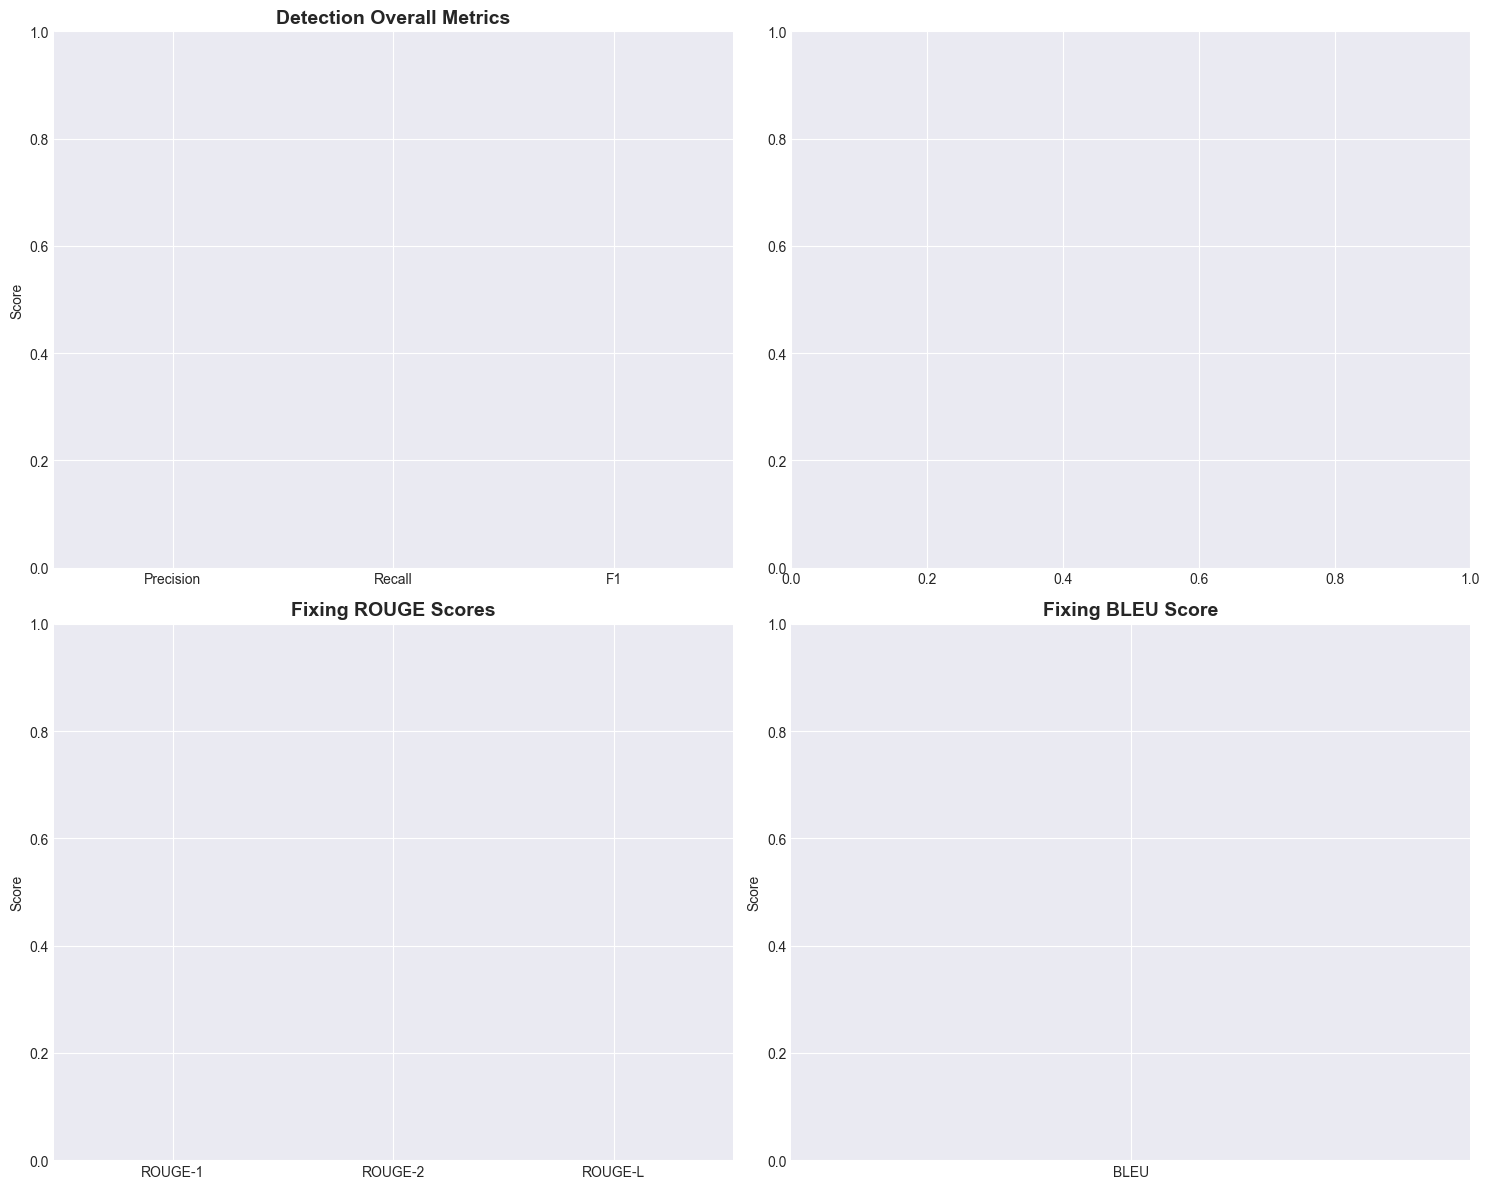


=== Inference Complete ===


In [82]:
# # Main Execution
# def main():
#     """Main execution function"""
#     # Initialize model manager
#     detection_path = "./models/detection_merged"
#     fixing_path = "./models/fixing_merged"

#     print("=== Initializing Model Manager ===")
#     model_manager = ModelManager(detection_path, fixing_path)

#     # Load models
#     print("\n=== Loading Models ===")
#     model_manager.load_detection_model()
#     model_manager.load_fixing_model()

#     # Prepare validation datasets
#     val_datasets = {
#         "detection": processed_detection_val,
#         "fixing": processed_fixing_val
#     }

#     # Run parallel inference
#     print("\n=== Starting Parallel Inference ===")
#     results = parallel_inference_pipeline(
#         model_manager,
#         val_datasets,
#         batch_size=4,
#         num_workers=2
#     )

#     # Calculate metrics
#     print("\n=== Calculating Metrics ===")
#     detection_metrics = calculate_detection_metrics(results)
#     fixing_metrics = calculate_fixing_metrics(results)

#     all_metrics = {
#         "detection": detection_metrics,
#         "fixing": fixing_metrics
#     }

#     # Print summary
#     print("\n=== Metrics Summary ===")
#     print(f"Detection - Precision: {detection_metrics['overall']['precision']:.3f}, "
#           f"Recall: {detection_metrics['overall']['recall']:.3f}, "
#           f"F1: {detection_metrics['overall']['f1']:.3f}")
#     print(f"Fixing - ROUGE-L: {fixing_metrics['rouge']['rougeL']:.3f}, "
#           f"BLEU: {fixing_metrics['bleu']:.3f}")

#     # Save and visualize results
#     print("\n=== Saving Results ===")
#     save_results(results, all_metrics)
#     visualize_metrics(all_metrics)

#     # Clean up
#     del model_manager
#     gc.collect()
#     torch.cuda.empty_cache()

#     print("\n=== Inference Complete ===")

# # Run the main function
# if __name__ == "__main__":
#     main()

In [37]:
# Step 1: Load quantized model and tokenizer
model_name = "deepseek-ai/deepseek-coder-1.3b-instruct"
merged_path = "./models/detection_merged"  # Update if different

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=quant_config,
    device_map="auto"  # Auto offload to GPU/CPU
)
model = PeftModel.from_pretrained(model, merged_path).merge_and_unload()  # Load and merge LoRA
model.eval()  # Evaluation mode

# Step 2: Prepare a simple prompt with sample C++ snippet
code_snippet = """
void Update() {
    GameObject* obj = new GameObject();  // Potential smell: allocation in update
    // Heavy logic here
    delete obj;
}
"""
instruction = f"Detect code smells in this C++ code: {code_snippet}"
prompt = f"[INST] {DETECTION_SYSTEM_PROMPT}\n\n{instruction} [/INST]"

# Step 3: Tokenize and generate output
inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        max_new_tokens=256,  # Limit for efficiency
        do_sample=False,     # Deterministic output
        temperature=0.1,     # Low for consistency
        eos_token_id=tokenizer.eos_token_id
    )

# Step 4: Decode and extract JSON output
generated_text = tokenizer.decode(outputs[0], skip_special_tokens=True)
json_output = generated_text.split("[/INST]")[1].strip()  # Extract post-prompt part

print("Detected Smells JSON:")
print(json_output)

ValueError: Can't find 'adapter_config.json' at './models/detection_merged'